The data collection period for spring 2025 (period 01) has a special treatment. 
<br>

The measurements taking during this period were affected by a tape and tools inside of the lead castle. Furthermore, in the IC reconstruction process, the Q threshold used was 7 PE. For this reason, we reprocessed some runs from period 02 by applying a cut-off to the Q value so that they would comparable with processed runs from period 01.
<br>

In this notebook we:

- Load hit & event-level dataframe.
- Check minimum Q value in each run.
- Tag events by particle and detector region.
- Use HE scale and perform trigger02 efficiency cut.
- Count the fiducial events (electrons) with $nS2=1$.
- Update summary.

We then defined a rescaling factor to reuse the information from period 01.
<br>
This is particularly important for the correlation with LSC measurements in the case of RAS = off.

In [1]:
import sys
sys.path.append('/lhome/ific/c/ccortesp/Analysis/')

from libs import bckg_functions as bf
from libs import crudo
from libs import fit_functions as ff
from libs import plotting_tools as pt

import numpy as np
import os
import pandas as pd
import scipy
from   iminuit      import Minuit
from   iminuit.cost import LeastSquares
import matplotlib.pyplot as plt 

# Styling Plot
pt.ccortesp_plot_style()

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Preliminary

In [2]:
# --------------------
# 1. FILES INFORMATION
# --------------------
# Filenames tag
VERSION_TAG = 'rescale_p1'

# Directory
PROCESSED_DIR = '/lustre/ific.uv.es/prj/gl/neutrinos/users/ccortesp/NEXT-100/Backgrounds/h5/runs/'

# --------------------------------
# 2. ALPHA/ELECTRON DISCRIMINATION
# --------------------------------
S1_ENERGY_THRESHOLD = 900     # in [PE]
SIZE_THRESHOLD = 2e3          # in [# of hits]

# -------------------
# 3. DETECTOR REGIONS
# -------------------
# Geometric boundaries for event classification.
Z_LOW = 40          # in [mm]
Z_UP  = 1147        # in [mm]
R_UP  = 451.65      # in [mm]

# ------------
# 4. SELECTION
# ------------
# HE scale correction
M_HE_SCALE = 4.80e-06
B_HE_SCALE = 0.0094         # in [MeV]
DEP_CORRECTION = 0.0695     # in [MeV], ajustando al DEP

# ----- Trigger 2 Efficiency Cut ----- #
# Events with event-level energy below this are removed to account for trigger efficiency.
TRG2_THRESHOLD = 0.5        # in [MeV]

### Load Runs & Summary Information

In [3]:
# ----- Main Directories ----- #
RUNS_INFO_DIR = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/utilities/'
SUMMARY_DIR   = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/'

# ----- Filenames ----- #
SUMMARY_NAME = f'summary_{VERSION_TAG}_processed.csv'

# ----- Load Dataframes ----- #
RUNS_INFO_DF = pd.read_csv(os.path.join(RUNS_INFO_DIR, f'runs_information.csv'))
RUNS_INFO_DF.columns = RUNS_INFO_DF.columns.str.strip()

SUMMARY_DF   = pd.read_csv(os.path.join(SUMMARY_DIR, SUMMARY_NAME))
SUMMARY_DF.drop(columns=['Unnamed: 0'], inplace=True)
SUMMARY_DF.columns = SUMMARY_DF.columns.str.strip()
SUMMARY_DF.sort_values(by='Run_ID', inplace=True)

#### Which runs will you analyze?

Sometimes we'll analyze by _data period_, sometimes by _detector condition_ or sometimes everything together

In [4]:
# ----- Configuration ----- #
DATA_PERIOD = 1                          # Options: None, 1, 2
DETECTOR_CONDITION = 'castle_pclosed'        # Options: None, 'castle_open', 'castle_closed', 'castle_closed_RAS', 'castle_pclosed', 'castle_pclosed_RAS'

In [5]:
selection_mask = pd.Series(True, index=RUNS_INFO_DF.index)

runs_in_summary = SUMMARY_DF['Run_ID'].unique()
print(f"→ Must be one of the {len(runs_in_summary)} runs in the summary")
selection_mask &= RUNS_INFO_DF['run_number'].isin(runs_in_summary)

if DATA_PERIOD is not None:
    print(f"→ Period == {DATA_PERIOD}")
    # The '&=' operator is a shortcut for 'selection_mask = selection_mask & ...'
    selection_mask &= (RUNS_INFO_DF['period'] == DATA_PERIOD)

if DETECTOR_CONDITION is not None:
    print(f"→ Condition == '{DETECTOR_CONDITION}'")
    selection_mask &= (RUNS_INFO_DF['condition'] == DETECTOR_CONDITION)

RUNS_TO_ANALYZE = RUNS_INFO_DF.loc[selection_mask, 'run_number'].values
print(f"\nSelected {len(RUNS_TO_ANALYZE)} runs for analysis:\n{RUNS_TO_ANALYZE}")

EVT_COUNT_PER_RUN = {run: {'Trg2_Cut': 0, 'nElectrons': 0, 'S2_Cut': 0, 'nElectron_Fiducial': 0} for run in RUNS_TO_ANALYZE}
print(f"\nDictionary for new event counts initialized.")

→ Must be one of the 45 runs in the summary
→ Period == 1
→ Condition == 'castle_pclosed'

Selected 16 runs for analysis:
[15299 15318 15319 15330 15331 15332 15462 15472 15478 15479 15484 15485
 15486 15487 15488 15489]

Dictionary for new event counts initialized.


# Tagging & Analysis Workflow

## Testing

In [ ]:
# Select a random run to test the workflow
id_test = np.random.choice(RUNS_TO_ANALYZE)
print(f"Randomly selected run for testing: {id_test}")
test_path = os.path.join(PROCESSED_DIR, f'processed_run_{id_test}_{VERSION_TAG}.h5')

# Load dataframes
test_evt_df = pd.read_hdf(test_path, key='Events')
test_hit_df = pd.read_hdf(test_path, key='Hits')

Randomly selected run for testing: 15462


In [12]:
# ----- Event Tagging ----- #
test_evt_df = bf.tag_particles(test_evt_df, size_threshold=SIZE_THRESHOLD, s1_energy_threshold=S1_ENERGY_THRESHOLD)
test_evt_df = bf.tag_event_by_detector_region(test_evt_df, z_cut_low=Z_LOW, z_cut_high=Z_UP, r_cut_high=R_UP)
print(f"{test_evt_df['event'].nunique()} events loaded and tagged.")
test_evt_df

8532 events loaded and tagged.


,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,E_evt_pe,n_hits,time,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,particle,region
0,596,4,2.642341e+05,423,103.519904,436.276352,670.408615,658.613163,685.459086,500.649629,2.642341e+05,423,1.747928e+09,1,1,1255.538818,1600.511318,538,alpha,tube
1,1065,37,5.861387e+04,124,-137.424704,-168.615244,15.200622,12.152277,21.601969,288.315905,5.861387e+04,124,1.747929e+09,0,1,NaN,NaN,159,electron,anode
2,2626,0,6.684924e+05,3134,130.048436,-184.821893,938.479022,925.418304,955.917879,492.112107,6.684924e+05,3134,1.747929e+09,1,1,802.319397,895.200855,3824,electron,tube
3,2913,36,9.763438e+04,173,305.042907,-1.113121,35.888138,24.334288,45.654484,367.828039,9.763438e+04,173,1.747929e+09,0,1,NaN,NaN,248,electron,anode
4,3760,27,1.276840e+05,185,29.982628,-461.682612,517.215087,507.306065,527.018766,485.471509,1.276840e+05,185,1.747929e+09,1,1,1213.546509,1685.001760,223,alpha,tube
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9584,1588832,10,2.625803e+05,306,-387.019458,-247.827220,212.041975,205.625746,221.823411,496.294324,2.625803e+05,306,1.747968e+09,1,1,827.930115,1396.032946,513,alpha,tube
9585,1589728,0,1.208133e+06,6122,-255.404045,68.725613,478.110718,464.543168,490.867172,492.864820,1.208133e+06,6122,1.747968e+09,1,1,1169.825806,1661.698771,6249,alpha,tube
9586,1590526,20,1.699440e+05,383,-17.822053,-428.141758,254.139785,239.856931,287.304884,482.545911,1.699440e+05,383,1.747968e+09,1,1,138.716522,228.199898,432,electron,tube
9587,1593095,1,3.534864e+05,564,450.547079,39.262465,735.358089,724.446799,751.422040,498.389262,3.534864e+05,564,1.747968e+09,1,1,1137.866943,1402.618887,765,alpha,tube


In [16]:
# ----- Trg2 Efficiency Cut ----- #
# Convert from [pe] to [MeV] using HE scale
test_evt_df = bf.energy_pe_to_mev(test_evt_df, slope=M_HE_SCALE, intercept=B_HE_SCALE - DEP_CORRECTION, input_column='E_evt_pe', output_column='E_evt_mev')
test_evt_df = test_evt_df[test_evt_df['E_evt_mev'] >= TRG2_THRESHOLD].copy()
print(f"→ After trigger2 cut: {test_evt_df['event'].nunique()} events.")

# ----- Inclusive Electrons ----- #
test_evt_electrons = test_evt_df[test_evt_df['particle'] == 'electron'].copy()
print(f"  of which are electrons: {test_evt_electrons['event'].nunique()} events.")

# ----- Fiducial Electrons ----- #
# nS2 = 1
test_evt_fiducial = test_evt_electrons[test_evt_electrons['nS2'] == 1].copy()
print(f"→ After nS2 = 1 cut: {test_evt_fiducial['event'].nunique()} events.")
# Fiducial region
test_evt_fiducial = test_evt_fiducial[test_evt_fiducial['region'] == 'fiducial'].copy()
print(f"→ After fiducial region selection: {test_evt_fiducial['event'].nunique()} events.")

→ After trigger2 cut: 7062 events.
  of which are electrons: 1025 events.
→ After nS2 = 1 cut: 843 events.
→ After fiducial region selection: 108 events.


In [17]:
test_evt_electrons

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,n_hits,time,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,particle,region,E_evt_mev
2,2626,0,668492.359090,3134,130.048436,-184.821893,938.479022,925.418304,955.917879,492.112107,...,3134,1.747929e+09,1,1,802.319397,895.200855,3824,electron,tube,3.148663
20,17823,5,294445.015688,435,-333.012929,310.260031,13.077326,5.594820,21.510604,526.105257,...,435,1.747929e+09,0,1,NaN,NaN,680,electron,anode,1.353236
23,20882,6,204587.607230,351,210.594925,207.168948,185.670439,171.761969,201.799094,366.818622,...,351,1.747929e+09,1,1,171.599579,293.451949,439,electron,fiducial,0.921921
25,22457,27,168267.847226,391,-383.976116,-225.111837,328.255425,295.865897,350.012735,483.192137,...,391,1.747929e+09,1,1,173.483246,269.759673,450,electron,tube,0.747586
33,30213,28,146067.404991,431,-49.211918,-162.778819,1173.401337,1156.949502,1190.843878,252.452038,...,431,1.747929e+09,1,1,190.520477,191.540136,498,electron,cathode,0.641024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9561,1563023,17,131502.525468,464,137.575345,-341.209230,1170.064617,1151.546712,1192.405419,443.814918,...,464,1.747967e+09,1,1,184.849823,186.528228,527,electron,cathode,0.571112
9565,1567384,15,176474.371570,477,-67.970913,118.336751,1009.472435,994.865261,1025.382245,221.574573,...,477,1.747967e+09,1,1,367.619476,397.156946,563,electron,fiducial,0.786977
9575,1579816,32,123519.502402,417,-67.749335,-162.890381,1172.125135,1155.475434,1192.960425,246.902858,...,417,1.747967e+09,1,1,162.382080,163.459904,460,electron,cathode,0.532794
9582,1586844,0,524096.305543,1304,321.811349,244.575912,6.077363,2.328904,21.651491,578.582441,...,1304,1.747968e+09,0,1,NaN,NaN,1995,electron,anode,2.455562


In [18]:
test_evt_fiducial

,event,npeak,E_peak_pe,n_hits_peak,X_bary,Y_bary,Z_bary,Z_min,Z_max,R_max,...,n_hits,time,nS1,nS2,S1e_max,S1e_corr_max,n_hits_original,particle,region,E_evt_mev
23,20882,6,204587.607230,351,210.594925,207.168948,185.670439,171.761969,201.799094,366.818622,...,351,1.747929e+09,1,1,171.599579,293.451949,439,electron,fiducial,0.921921
456,512303,9,203711.391624,580,145.865351,-68.984137,158.806191,123.178271,215.459174,232.582311,...,580,1.747941e+09,1,1,165.246979,290.302543,638,electron,fiducial,0.917715
652,737192,4,219000.177555,527,-127.181197,118.882743,100.451062,81.928151,118.794559,254.358470,...,527,1.747947e+09,1,1,161.310959,295.526606,623,electron,fiducial,0.991101
702,790847,0,339475.920334,1380,-274.979505,215.196651,997.527731,944.971845,1100.366933,451.021409,...,1380,1.747948e+09,1,1,400.671326,434.344402,1519,electron,fiducial,1.569384
750,830047,0,290733.894285,1099,-57.532166,221.174009,637.363817,569.667699,690.020123,311.204621,...,1099,1.747949e+09,1,1,279.276123,360.231417,1201,electron,fiducial,1.335423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8967,821667,19,180360.583341,613,322.499230,168.557245,920.926201,888.801016,947.206572,431.093936,...,613,1.747949e+09,1,1,227.882812,255.414044,690,electron,fiducial,0.805631
9085,995596,0,180146.149608,518,-165.211205,146.636809,270.270463,250.928715,291.523922,301.892193,...,518,1.747953e+09,1,1,138.663483,223.772965,579,electron,fiducial,0.804602
9304,1230621,6,229559.786222,728,140.936218,275.746688,739.714372,706.934225,761.879566,397.400052,...,728,1.747959e+09,1,1,236.177216,289.190045,800,electron,fiducial,1.041787
9477,1429904,29,129024.198076,393,-4.939183,307.549449,979.489777,960.954342,998.461499,384.031856,...,393,1.747964e+09,1,1,193.482666,211.683885,431,electron,fiducial,0.559216


Take a look to some event displays...

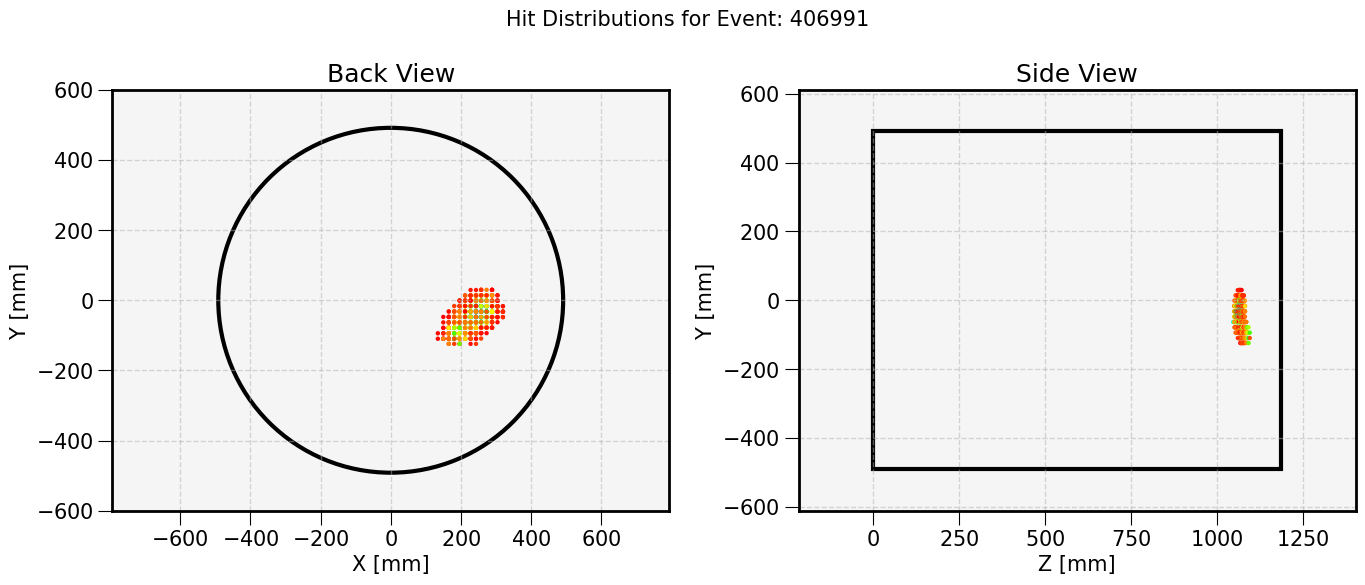

In [27]:
pt.event_display(test_hit_df, variable='E_hit_pe', event=np.random.choice(test_evt_fiducial['event'].unique()))

## Execution

In [6]:
for run_id in RUNS_TO_ANALYZE:

    print(f"--- Analyzing Run {run_id} ---")

    # ----- Load Dataframes ----- #
    run_path = os.path.join(PROCESSED_DIR, f'processed_run_{run_id}_{VERSION_TAG}.h5')
    df_event = pd.read_hdf(run_path, key='Events')
    # df_hits  = pd.read_hdf(run_path, key='Hits')

    # ----- Minimum Q Value ----- #
    # print(f"  Min. Q = {df_hits['Q'].min():.4f} PE\n")

    # ----- Event Tagging ----- #
    # By particle type
    df_event = bf.tag_particles(df_event, size_threshold=SIZE_THRESHOLD, s1_energy_threshold=S1_ENERGY_THRESHOLD)
    # By detector region
    df_event = bf.tag_event_by_detector_region(df_event, z_cut_low=Z_LOW, z_cut_high=Z_UP, r_cut_high=R_UP)

    # ----- Trg2 Efficiency Cut ----- #
    # Convert from [pe] to [MeV] using HE scale
    df_event = bf.energy_pe_to_mev(df_event, slope=M_HE_SCALE, intercept=B_HE_SCALE - DEP_CORRECTION, input_column='E_evt_pe', output_column='E_evt_mev')
    df_event = df_event[df_event['E_evt_mev'] >= TRG2_THRESHOLD].copy()
    EVT_COUNT_PER_RUN[run_id]['Trg2_Cut'] = int(df_event['event'].nunique())

    # ----- Inclusive Electrons ----- #
    df_event_electrons = df_event[df_event['particle'] == 'electron'].copy()
    EVT_COUNT_PER_RUN[run_id]['nElectrons'] = int(df_event_electrons['event'].nunique())

    # ----- Fiducial Electrons ----- #
    # nS2 = 1
    df_event_fiducial = df_event_electrons[df_event_electrons['nS2'] == 1].copy()
    EVT_COUNT_PER_RUN[run_id]['S2_Cut'] = int(df_event_fiducial['event'].nunique())
    # Fiducial region
    df_event_fiducial = df_event_fiducial[df_event_fiducial['region'] == 'fiducial'].copy()
    EVT_COUNT_PER_RUN[run_id]['nElectron_Fiducial'] = int(df_event_fiducial['event'].nunique())

print("Y ya, eso es todo, eso es todo ♥")

--- Analyzing Run 15299 ---


--- Analyzing Run 15318 ---
--- Analyzing Run 15319 ---
--- Analyzing Run 15330 ---
--- Analyzing Run 15331 ---
--- Analyzing Run 15332 ---
--- Analyzing Run 15462 ---
--- Analyzing Run 15472 ---
--- Analyzing Run 15478 ---
--- Analyzing Run 15479 ---
--- Analyzing Run 15484 ---
--- Analyzing Run 15485 ---
--- Analyzing Run 15486 ---
--- Analyzing Run 15487 ---
--- Analyzing Run 15488 ---
--- Analyzing Run 15489 ---
Y ya, eso es todo, eso es todo ♥


# Update Summary

In [7]:
# Convert dictionary to DataFrame
SELECT_SUMMARY_DF = pd.DataFrame.from_dict(EVT_COUNT_PER_RUN, orient='index')
SELECT_SUMMARY_DF.rename_axis("Run_ID", inplace=True)
SELECT_SUMMARY_DF.reset_index(inplace=True)
SELECT_SUMMARY_DF

,Run_ID,Trg2_Cut,nElectrons,S2_Cut,nElectron_Fiducial
0,15299,9721,1735,1225,204
1,15318,15936,2528,2166,338
2,15319,15406,2365,1982,305
3,15330,15361,2402,1920,302
4,15331,15029,2281,1841,293
5,15332,11958,1883,1516,235
6,15462,7062,1025,843,108
7,15472,15433,2412,2012,300
8,15478,15646,2544,2160,322
9,15479,15607,2401,2017,343


In [8]:
# Let's drop the old columns from the SUMMARY_DF if they exist, to avoid duplicates
columns_to_update = SELECT_SUMMARY_DF.columns.drop('Run_ID')
SUMMARY_DF = SUMMARY_DF.drop(columns=columns_to_update, errors='ignore')

In [9]:
# Merge both dataframe
UPDATED_SUMMARY_DF = pd.merge(SUMMARY_DF, SELECT_SUMMARY_DF, on='Run_ID', how='left')
UPDATED_SUMMARY_DF

,Run_ID,Duration,Date_CV,Date_Err,OK,LOST,Reconstructed,Z_Positive,S1_Cut,Clean_Events,Trg2_Cut,nElectrons,S2_Cut,nElectron_Fiducial
0,15299,60204,1.747095e+09,146.9611,18014,8929,17411,14809,11554,11553,9721.0,1735.0,1225.0,204.0
1,15318,86706,1.747194e+09,172.3596,28735,10115,28043,24307,19081,19074,15936.0,2528.0,2166.0,338.0
2,15319,85823,1.747281e+09,174.1556,27973,10086,27274,23734,18553,18544,15406.0,2365.0,1982.0,305.0
3,15330,86462,1.747704e+09,171.3388,28157,10432,27508,23924,18485,18474,15361.0,2402.0,1920.0,302.0
4,15331,85389,1.747791e+09,172.0570,27390,9966,26800,23300,18121,18115,15029.0,2281.0,1841.0,293.0
5,15332,67758,1.747868e+09,154.4476,22010,8142,21445,18624,14434,14424,11958.0,1883.0,1516.0,235.0
6,15462,39365,1.747948e+09,115.9820,12847,4532,12533,10878,8534,8532,7062.0,1025.0,843.0,108.0
7,15472,86563,1.748048e+09,175.7367,28505,10015,27372,23881,18707,18699,15433.0,2412.0,2012.0,300.0
8,15478,86835,1.748210e+09,174.0899,28702,9999,27808,24299,18935,18924,15646.0,2544.0,2160.0,322.0
9,15479,86876,1.748297e+09,174.5319,28713,10036,27966,24290,19014,19008,15607.0,2401.0,2017.0,343.0


Pilas cuando quiera actualizar los datos de los runs para el factor de reescalamiento!

In [10]:
UPDATED_SUMMARY_DF.to_csv(os.path.join(SUMMARY_DIR, f'summary_{VERSION_TAG}_updated.csv'))
print('Done! Summary updated in:', os.path.join(SUMMARY_DIR, f'summary_{VERSION_TAG}_updated.csv'))

Done! Summary updated in: /lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/summary_rescale_p1_updated.csv


# Rescale Factor for RAS: ON

By now, we have to load again the summary dataframe, because for this analysis there is another version (v2).

### Load Runs & Summary Information

In [13]:
# ----- Main Directories ----- #
RUNS_INFO_DIR = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/utilities/'
SUMMARY_DIR   = '/lhome/ific/c/ccortesp/Analysis/NEXT-100/Backgrounds/txt/summaries/'

# ----- Filenames ----- #
SUMMARY_NAME = f'summary_rescale_p1_updated_v2.csv'

# ----- Load Dataframes ----- #
RUNS_INFO_DF = pd.read_csv(os.path.join(RUNS_INFO_DIR, f'runs_information.csv'))
RUNS_INFO_DF.columns = RUNS_INFO_DF.columns.str.strip()

SUMMARY_DF   = pd.read_csv(os.path.join(SUMMARY_DIR, SUMMARY_NAME))
SUMMARY_DF.drop(columns=['Unnamed: 0'], inplace=True)
SUMMARY_DF.columns = SUMMARY_DF.columns.str.strip()
SUMMARY_DF.sort_values(by='Run_ID', inplace=True)

#### Which runs will you analyze?

In [14]:
# ----- Configuration ----- #
DATA_PERIOD = None                          # Options: None, 1, 2
DETECTOR_CONDITION = 'castle_closed_RAS'        # Options: None, 'castle_open', 'castle_closed', 'castle_closed_RAS', 'castle_pclosed', 'castle_pclosed_RAS'

In [15]:
selection_mask = pd.Series(True, index=RUNS_INFO_DF.index)

runs_in_summary = SUMMARY_DF['Run_ID'].unique()
print(f"→ Must be one of the {len(runs_in_summary)} runs in the summary.")
selection_mask &= RUNS_INFO_DF['run_number'].isin(runs_in_summary)

if DATA_PERIOD is not None:
    print(f"→ Period == {DATA_PERIOD}")
    # The '&=' operator is a shortcut for 'selection_mask = selection_mask & ...'
    selection_mask &= (RUNS_INFO_DF['period'] == DATA_PERIOD)

if DETECTOR_CONDITION is not None:
    print(f"→ Condition == '{DETECTOR_CONDITION}'")
    selection_mask &= (RUNS_INFO_DF['condition'] == DETECTOR_CONDITION)

RUNS_TO_ANALYZE = RUNS_INFO_DF.loc[selection_mask, 'run_number'].values
print(f"\nSelected {len(RUNS_TO_ANALYZE)} runs for analysis:\n{RUNS_TO_ANALYZE}")

→ Must be one of the 45 runs in the summary.
→ Condition == 'castle_closed_RAS'

Selected 29 runs for analysis:
[15520 15521 15527 15528 15535 15539 15540 15541 15542 15543 15544 15545
 15546 15547 15557 15632 15633 15634 15635 15636 15637 15639 15640 15642
 15643 15644 15647 15648 15649]


In [22]:
# Storage
Date_CV = [];  Date_Err = []
Rate_CV = [];  Rate_Err = []
Run_numbers = []

# ----- Run Loop ----- #
for run_id in RUNS_TO_ANALYZE:

    if run_id in [15527, 15528, 15541, 15544, 15640, 15648, 15649]:
        print(f"Don't want outliers like Run {run_id}, skipping...\n")
        continue

    print(f"Processing Run {run_id}")

    # Run information
    duration = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'Duration'].values[0]
    OK_trg   = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'OK'].values[0]
    LOST_trg = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'LOST'].values[0]
    # DAQe efficiency + error
    DAQe_CV, DAQe_error = ff.efficiency(OK_trg, LOST_trg)
    Run_numbers.append(run_id)

    # Date + error for each run
    Date_CV.append(SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'Date_CV'].values[0])
    Date_Err.append(SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'Date_Err'].values[0])

    # Rate + error for each run
    fidu_evts = SUMMARY_DF.loc[SUMMARY_DF['Run_ID'] == run_id, 'nElectron_Fiducial'].values[0];    fidu_evts = int(fidu_evts)
    fidu_CV, fidu_var = scipy.stats.binom.stats(n=OK_trg, p=fidu_evts/OK_trg, moments='mv')
    print(f'  Fiducial Events = {fidu_CV:.2f}, Var = {fidu_var:.2f}, Duration = {duration} s, DAQe = {DAQe_CV:.4f} ± {DAQe_error:.4f}')

    # Fiducial rate + error
    rate_CV  = fidu_CV / (duration * DAQe_CV)
    rate_err = rate_CV * np.sqrt((np.sqrt(fidu_var) / fidu_CV)**2 + (DAQe_error / DAQe_CV)**2) 
    Rate_CV.append(rate_CV * 1e3)
    Rate_Err.append(rate_err * 1e3)
    print(f'  Rate = {rate_CV*1e3:.4f} ± {rate_err*1e3:.4f} mHz\n')

Processing Run 15520
  Fiducial Events = 231.00, Var = 229.10, Duration = 85170 s, DAQe = 0.7544 ± 0.0022
  Rate = 3.5950 ± 0.2358 mHz

Processing Run 15521
  Fiducial Events = 208.00, Var = 206.48, Duration = 85388 s, DAQe = 0.7628 ± 0.0022
  Rate = 3.1935 ± 0.2208 mHz

Don't want outliers like Run 15527, skipping...

Don't want outliers like Run 15528, skipping...

Processing Run 15535
  Fiducial Events = 229.00, Var = 227.18, Duration = 84904 s, DAQe = 0.7588 ± 0.0022
  Rate = 3.5547 ± 0.2342 mHz

Processing Run 15539
  Fiducial Events = 114.00, Var = 113.17, Duration = 56567 s, DAQe = 0.6197 ± 0.0031
  Rate = 3.2523 ± 0.3039 mHz

Processing Run 15540
  Fiducial Events = 173.00, Var = 171.67, Duration = 67663 s, DAQe = 0.7612 ± 0.0025
  Rate = 3.3588 ± 0.2546 mHz

Don't want outliers like Run 15541, skipping...

Processing Run 15542
  Fiducial Events = 233.00, Var = 231.17, Duration = 87915 s, DAQe = 0.7622 ± 0.0022
  Rate = 3.4774 ± 0.2271 mHz

Processing Run 15543
  Fiducial Event

In [23]:
def const_func(x, a):
    return ff.linear_func(x, 0, a)

# Storage
Period_info = {1: {}, 2: {}}

# Important date
P2_START = 1753178400       # Start of period 02

# ----- Linear Fit ----- #
# Preliminary
Date_CV  = np.array(Date_CV);        Date_Err = np.array(Date_Err)
Rate_CV  = np.array(Rate_CV);        Rate_Err = np.array(Rate_Err)

# Masking for each period
P1_time = (Date_CV < P2_START);      P2_time = (Date_CV >= P2_START)

for i, period in enumerate([P1_time, P2_time]):

    print(f'--- Period 0{i+1} ---')

    # Data selection
    x_data = Date_CV[period]
    y_data = Rate_CV[period]
    y_err  = Rate_Err[period]

    # Shifted time
    x_shift = (x_data - x_data[0]) / 3600   # In [hr] for numeric stability

    # Define the cost function + initial guess
    least_squares = LeastSquares(x_shift, y_data, y_err, const_func)
    init_guess = [y_data.min()]

    # print(f'\nFit 0{i+1}:\nInitial guess: {init_guess}')

    # Define the Minuit object
    m = Minuit(least_squares, *init_guess)

    # Minimization process of the cost function and error estimation
    m.migrad()
    m.hesse()

    # Results
    popt = m.values;  perr = m.errors
    print(f"Rate of Fiducial Background: ({popt[0]:.2f} ± {perr[0]:.2f}) mHz")
    Period_info[i+1]['Rate_CV']  = popt[0]
    Period_info[i+1]['Rate_Err'] = perr[0]

    # Reduced chi-square
    chi2 = m.fval
    ndof = len(x_shift) - m.nfit
    print(f"χ² / ndof = {chi2 / ndof:.4f}\n")
    Period_info[i+1]['Red_Chi2'] = chi2 / ndof

    # Fits
    x_fit = (x_shift * 3600) + x_data[0]  # In [s]
    y_fit = const_func(x_shift, *popt)
    Period_info[i+1]['x_fit'] = x_fit
    Period_info[i+1]['y_fit'] = y_fit

--- Period 01 ---
Rate of Fiducial Background: (3.41 ± 0.07) mHz
χ² / ndof = 0.3672

--- Period 02 ---
Rate of Fiducial Background: (3.08 ± 0.07) mHz
χ² / ndof = 0.2583



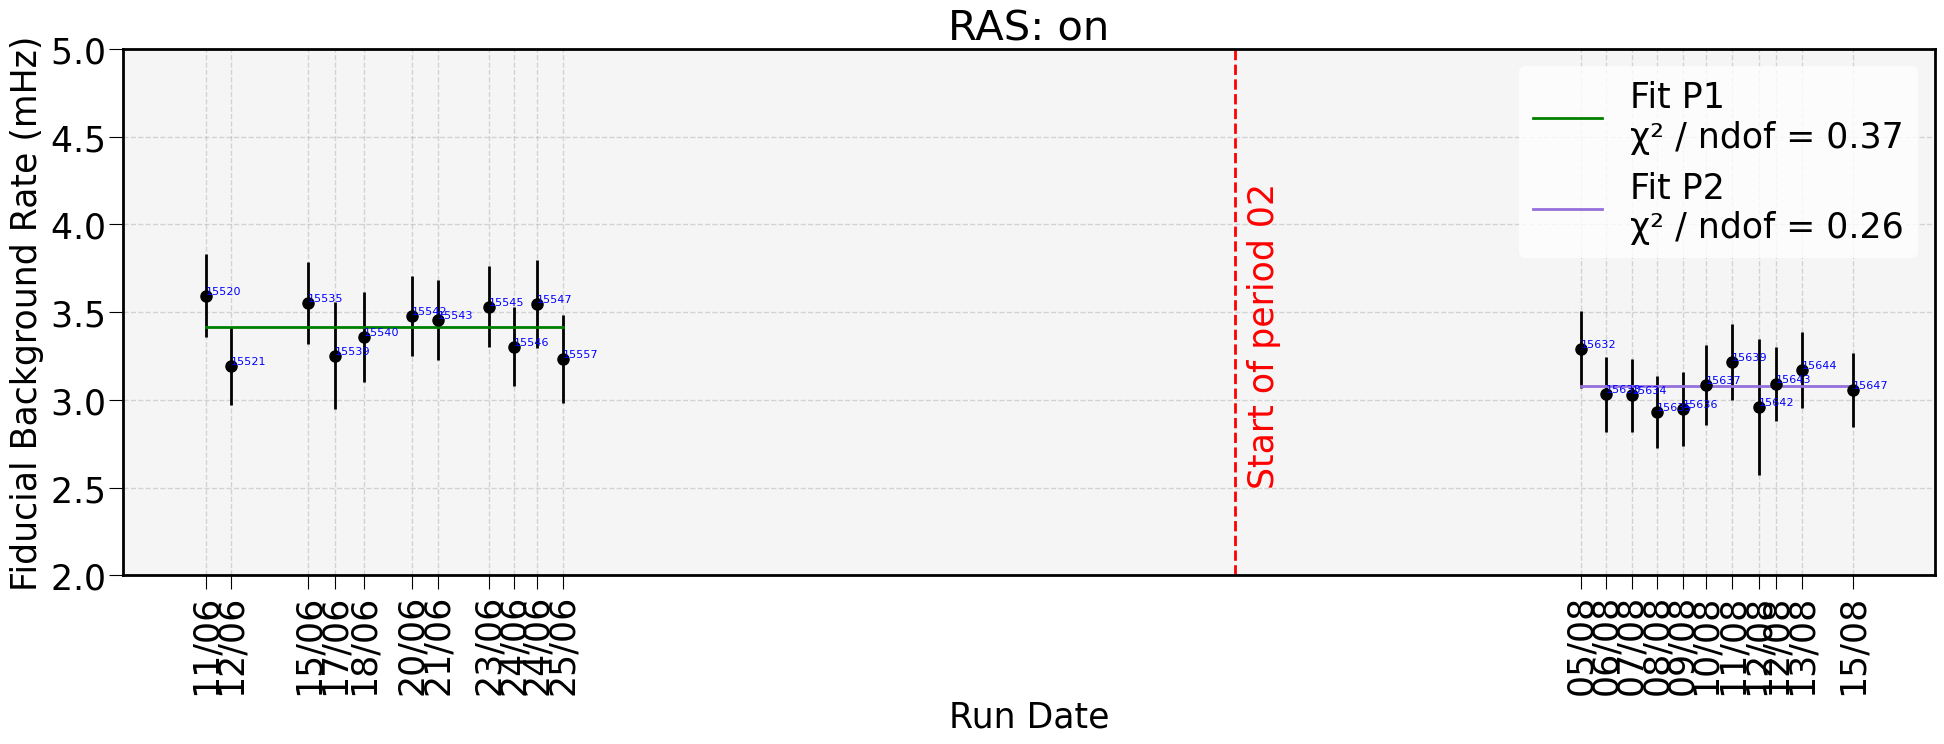

Ratio of Rates (P2 / P1): R = 0.9013 ± 0.0273


In [24]:
# ----- Plotting ----- #
plt.figure(figsize=(20, 8))

# Data
plt.errorbar(Date_CV, Rate_CV, xerr=Date_Err, yerr=Rate_Err, fmt='o', c='black', ecolor='black')
for x, y, run_id in zip(Date_CV, Rate_CV, Run_numbers):
    plt.text(x, y, str(run_id), fontsize=8, ha='left', va='bottom', color='blue')       # Run number near the point

# Fits
for i in [1, 2]:
    plt.plot(Period_info[i]['x_fit'], Period_info[i]['y_fit'], color=pt.hist_colors[4*i % len(pt.hist_colors)], ls='-', label=f'Fit P{i}\nχ² / ndof = {Period_info[i]["Red_Chi2"]:.2f}')

# Important dates
plt.axvline(x=P2_START, color='red', ls='--')
plt.text(P2_START + 4e4, 2.5, 'Start of period 02', color='red', ha='left', va='bottom', rotation=90)

# Styling
x_labels = [crudo.epoch_converter(t, h=False) for t in Date_CV]        # Convert x-axis bin edges to readable time format
plt.xticks(Date_CV, x_labels, rotation=90, ha='center')
plt.xlabel('Run Date')
plt.ylabel('Fiducial Background Rate (mHz)')
plt.ylim(2.0, 5.0)
plt.legend(loc='upper right')
plt.title('RAS: on')

plt.grid(True)
plt.gca().set_facecolor("whitesmoke")
plt.tight_layout()
plt.show()

# ---- Ratio of Rates (RAS = on) ---- #
R_CV  = Period_info[2]['Rate_CV'] / Period_info[1]['Rate_CV']
R_Err = R_CV * np.sqrt( (Period_info[1]['Rate_Err'] / Period_info[1]['Rate_CV'])**2 + (Period_info[2]['Rate_Err'] / Period_info[2]['Rate_CV'])**2 )
print(f'Ratio of Rates (P2 / P1): R = {R_CV:.4f} ± {R_Err:.4f}')